# **IMPORT LIBRARIES**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# **DATASET LOADING & DESCRIPTION**

In [38]:
# Loading Dataset

df = pd.read_csv("Customer_Category_Classifier_Dataset.csv")

In [39]:
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [40]:
df.tail()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B
8067,461879,Male,Yes,37,Yes,Executive,0.0,Average,3.0,Cat_4,B


In [41]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [42]:
df.describe()


,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [43]:
df.describe(include='object')


,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
count,8068,7928,7990,7944,8068,7992,8068
unique,2,2,2,9,3,7,4
top,Male,Yes,Yes,Artist,Low,Cat_6,D
freq,4417,4643,4968,2516,4878,5238,2268


In [44]:
df.isnull().sum()


,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [45]:
# Percentage of missing values
(df.isnull().mean() * 100).sort_values(ascending=False)


,0
Work_Experience,10.275161
Family_Size,4.152206
Ever_Married,1.735250
Profession,1.536936
Graduated,0.966782
Var_1,0.941993
ID,0.000000
Gender,0.000000
Age,0.000000
Spending_Score,0.000000


In [46]:
df.duplicated().sum()


np.int64(0)

In [47]:
# Defining Columns (Features)

numerical_cols = ['Age', 'Work_Experience', 'Family_Size']
categorical_cols = ['Gender', 'Ever_Married', 'Graduated',
                    'Profession', 'Spending_Score', 'Var_1']
target_col = 'Segmentation'

In [48]:
# Target variable distribution
df[target_col].value_counts()


,count
Segmentation,
D,2268
A,1972
C,1970
B,1858


In [49]:
# Target variable distribution (percentage)
df[target_col].value_counts(normalize=True) * 100


,proportion
Segmentation,
D,28.111056
A,24.442241
C,24.417452
B,23.029251


In [50]:
# Unique values in categorical columns
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].unique())



Gender unique values:
['Male' 'Female']

Ever_Married unique values:
['No' 'Yes' nan]

Graduated unique values:
['No' 'Yes' nan]

Profession unique values:
['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]

Spending_Score unique values:
['Low' 'Average' 'High']

Var_1 unique values:
['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' nan 'Cat_5']


In [51]:
# Value counts for categorical features
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())



Value counts for Gender:
Gender
Male      4417
Female    3651
Name: count, dtype: int64

Value counts for Ever_Married:
Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64

Value counts for Graduated:
Graduated
Yes    4968
No     3022
Name: count, dtype: int64

Value counts for Profession:
Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

Value counts for Spending_Score:
Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

Value counts for Var_1:
Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64


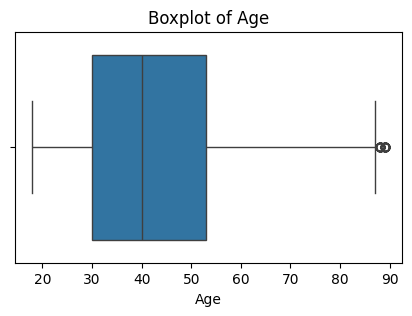

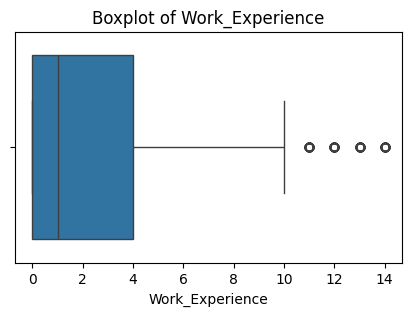

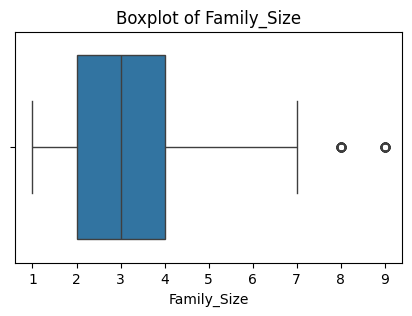

In [52]:
# Boxplots to detect outliers in numerical features
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


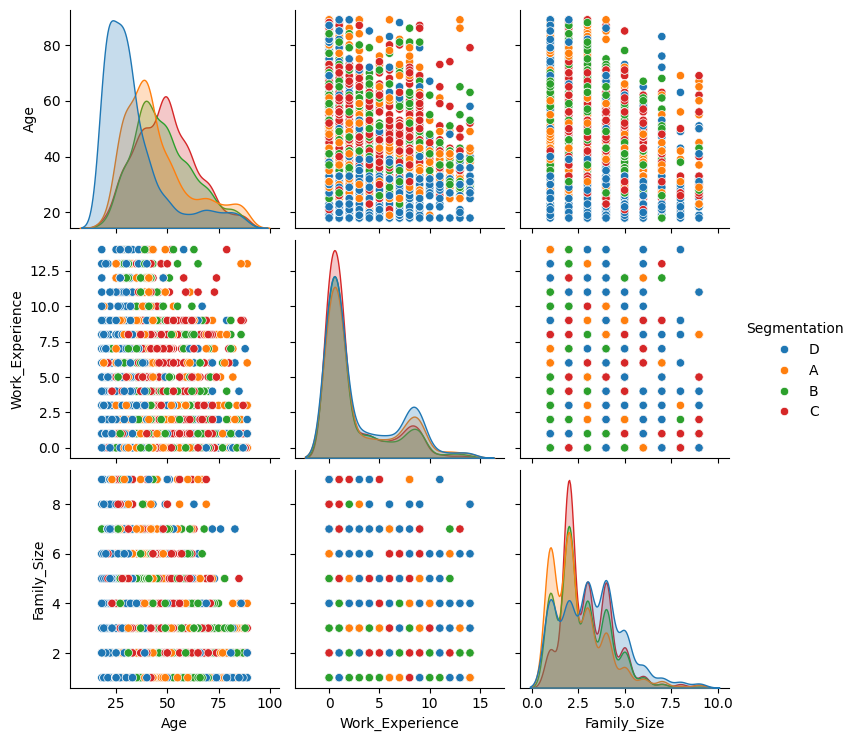

In [53]:
# Pairwise relationships between numerical features
sns.pairplot(df[numerical_cols + [target_col]], hue=target_col)
plt.show()


In [54]:
# Skewness of numerical features
df[numerical_cols].skew()


,0
Age,0.696021
Work_Experience,1.306226
Family_Size,1.010804


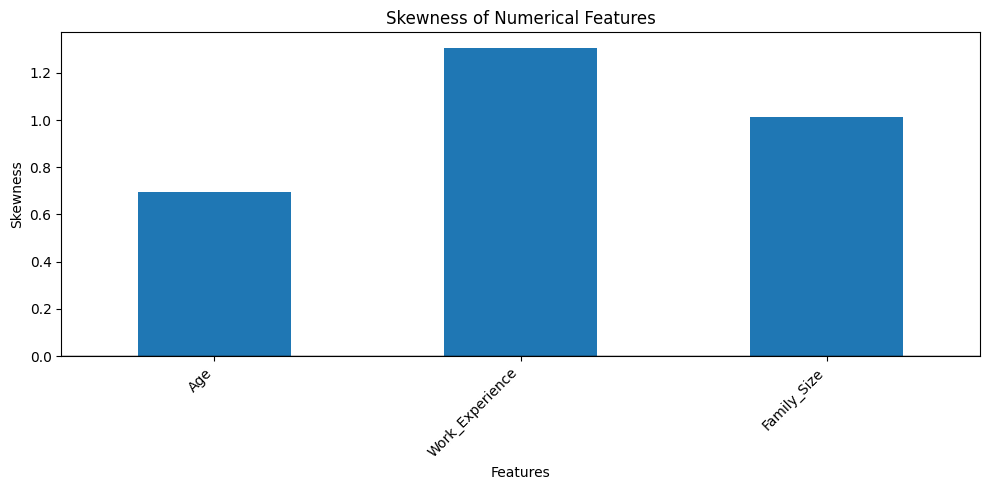

In [55]:
# Compute skewness
skewness = df[numerical_cols].skew()

# Plot skewness
plt.figure(figsize=(10, 5))
skewness.plot(kind='bar')
plt.axhline(0, color='black', linewidth=1)
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [56]:
df.drop(columns=['ID'], inplace=True)

print("--- After Dropping the Column 'ID' which does not impact model performance ---\n")
print("Dataset Shape:", df.shape, "\n")
shape = df.shape
row, col = shape[0], shape[1]
print(f"No. of Row: {row}\nNo. of Column: {col}")
print("Problem Type: Multi-class Classification\n")

--- After Dropping the Column 'ID' which does not impact model performance ---

Dataset Shape: (8068, 10) 

No. of Row: 8068
No. of Column: 10
Problem Type: Multi-class Classification



In [57]:
df.head(5)


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


# **EXPLORATORY DATA ANALYSIS (EDA)**


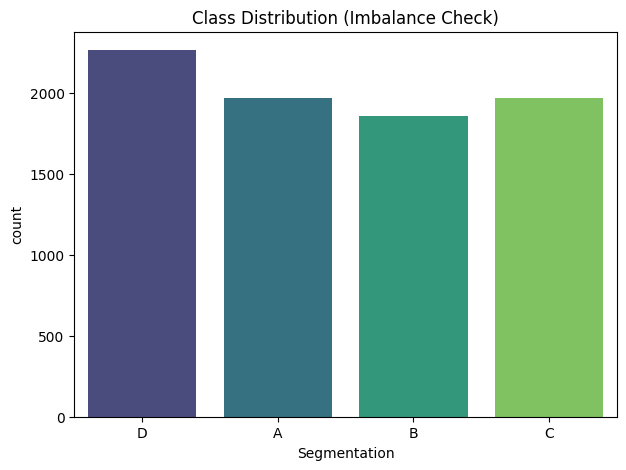

In [58]:
# Imbalance Check

plt.figure(figsize=(7,5))
sns.countplot(x=target_col, data=df, palette='viridis')
plt.title("Class Distribution (Imbalance Check)")
plt.show()


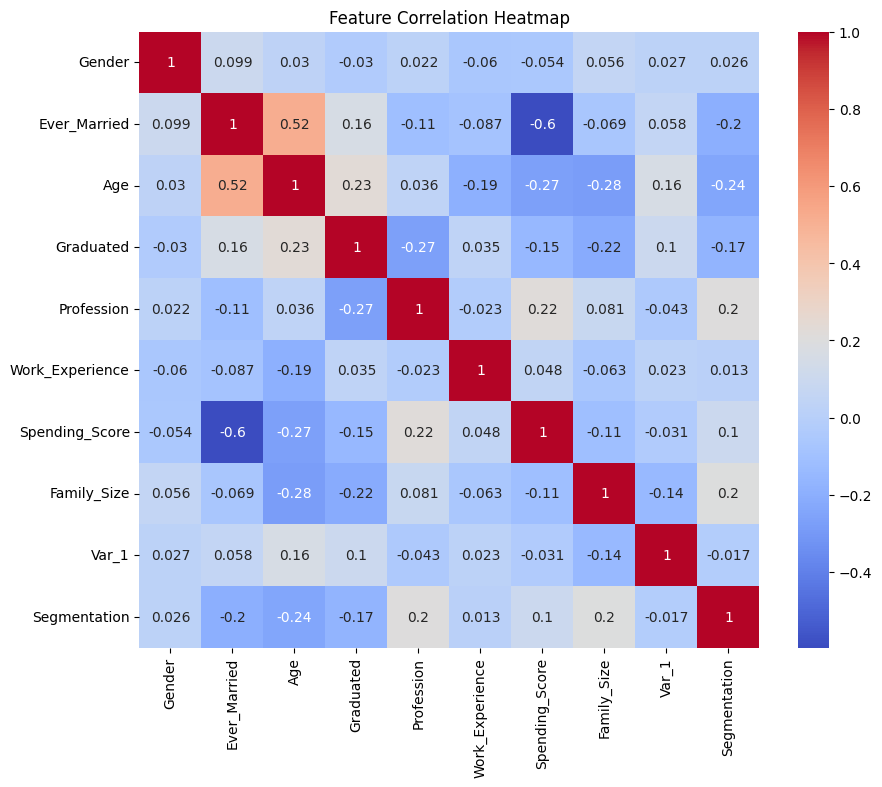

In [59]:
# Correlation Heatmap
df_corr = df.copy()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

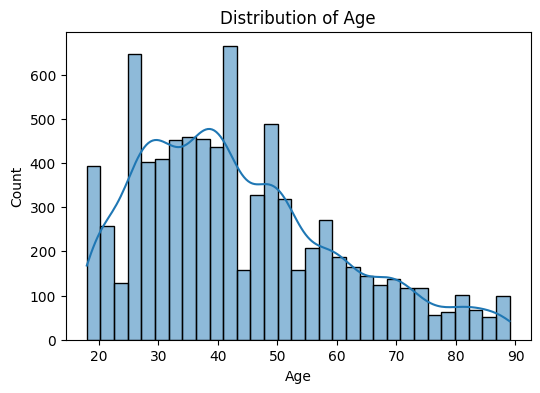

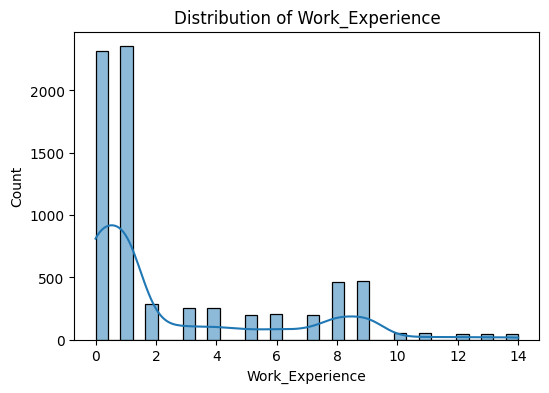

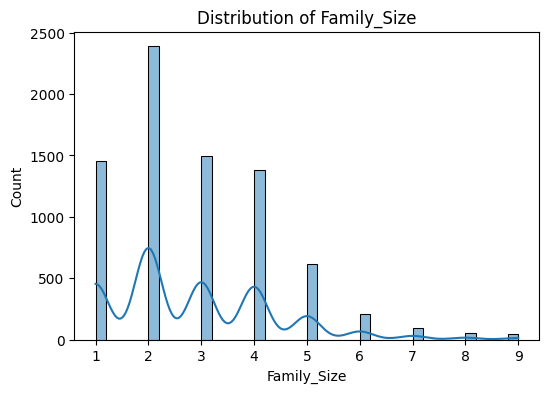

In [60]:
# Distribution Plots of Numerical Features
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


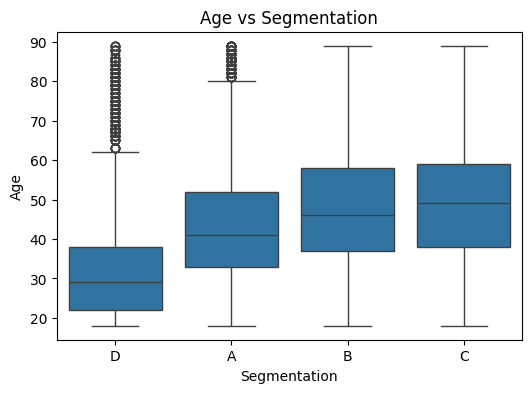

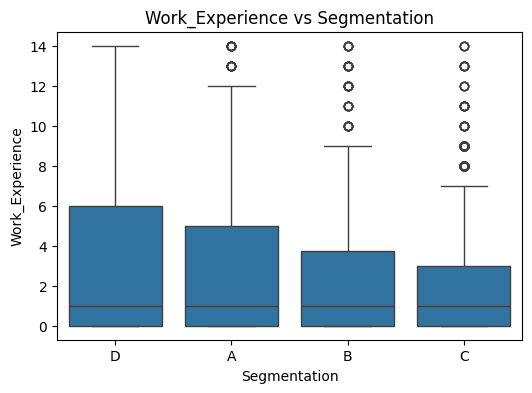

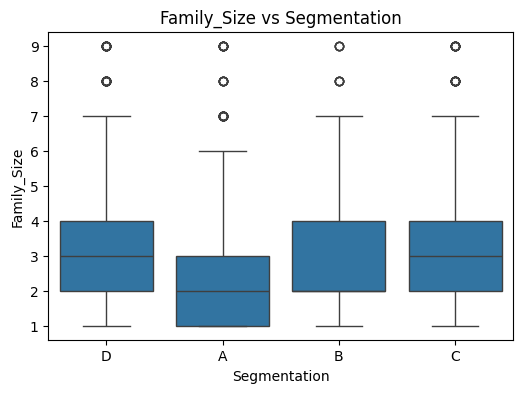

In [61]:
# Feature vs Target (Numerical vs Target)
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} vs Segmentation")
    plt.show()


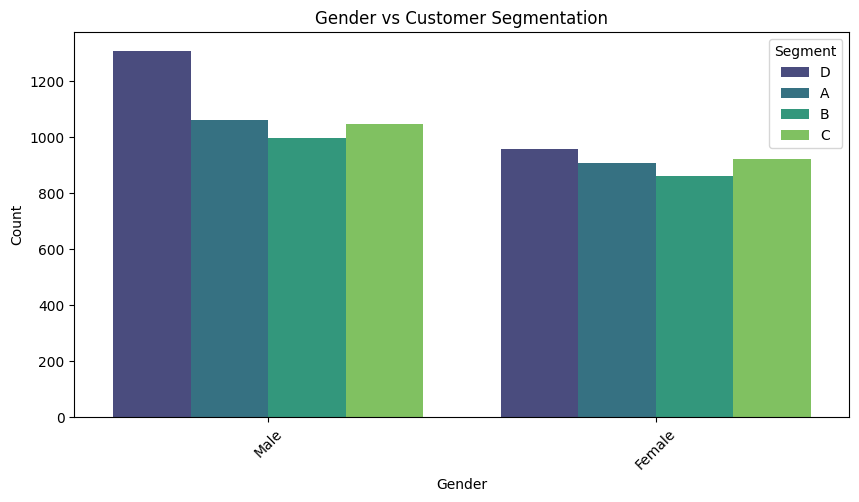

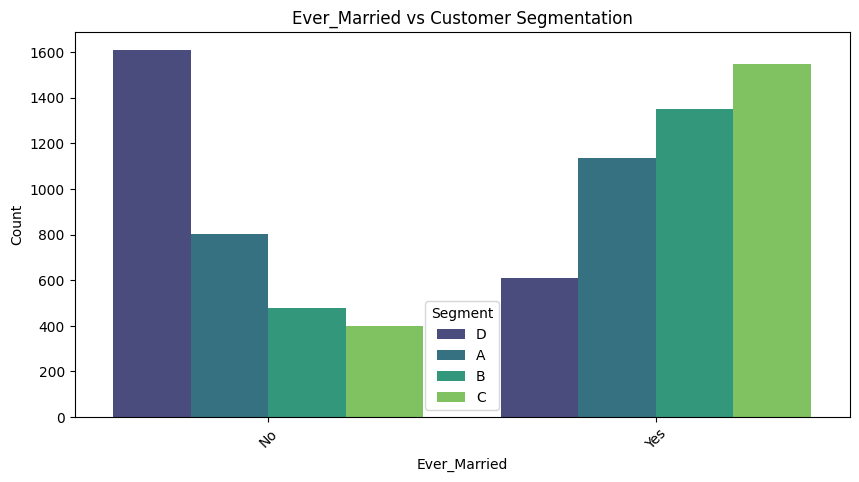

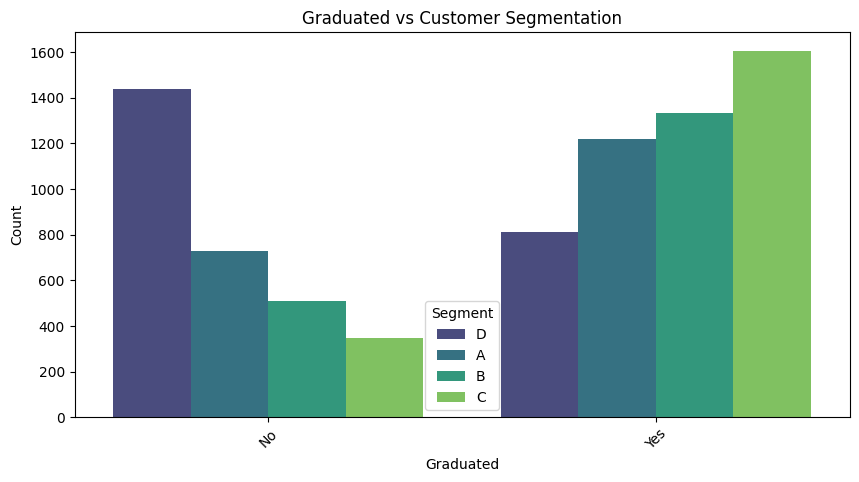

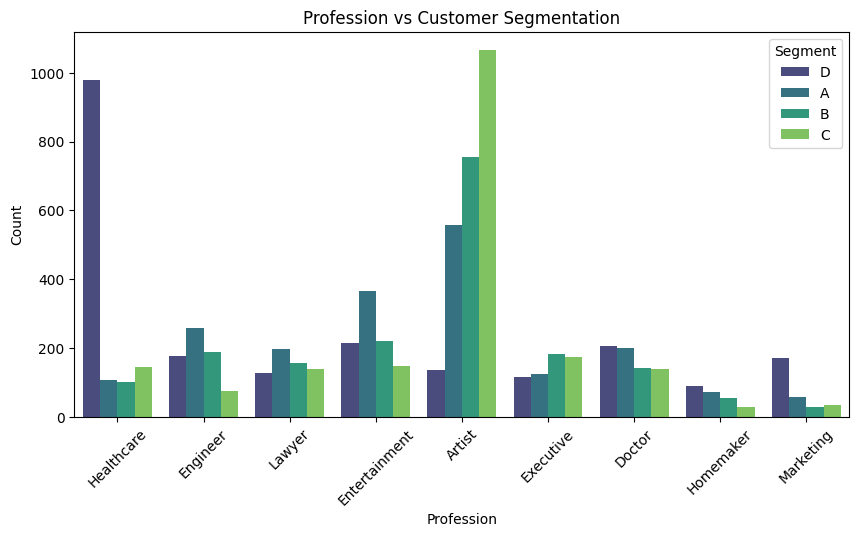

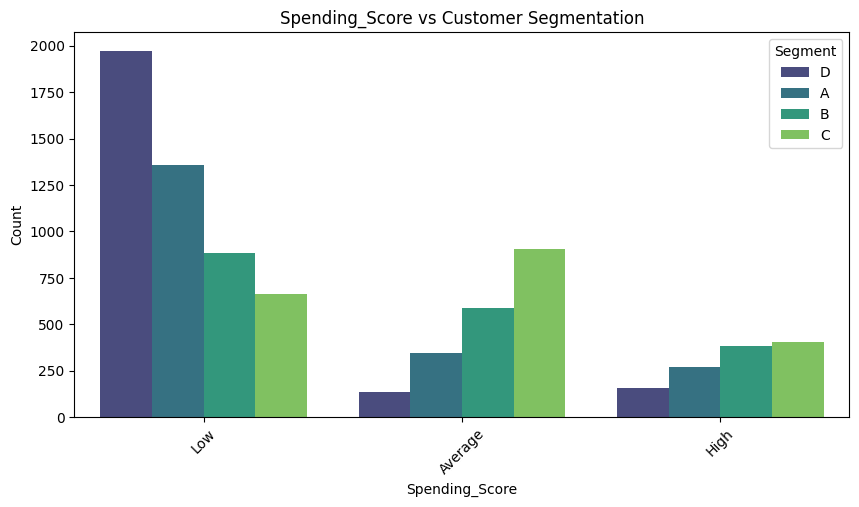

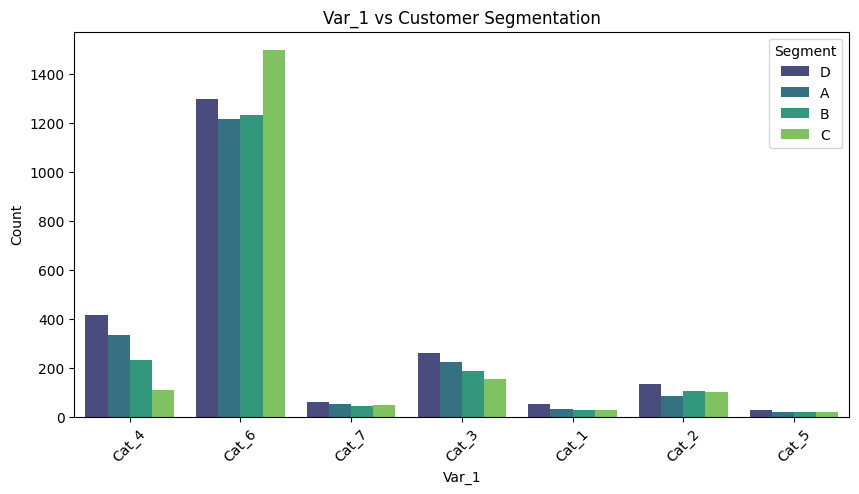

In [62]:
# Categorical vs Target (Target Feature = Segmentation)

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, hue=target_col, data=df, palette='viridis')
    plt.title(f"{col} vs Customer Segmentation")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Segment")
    plt.show()


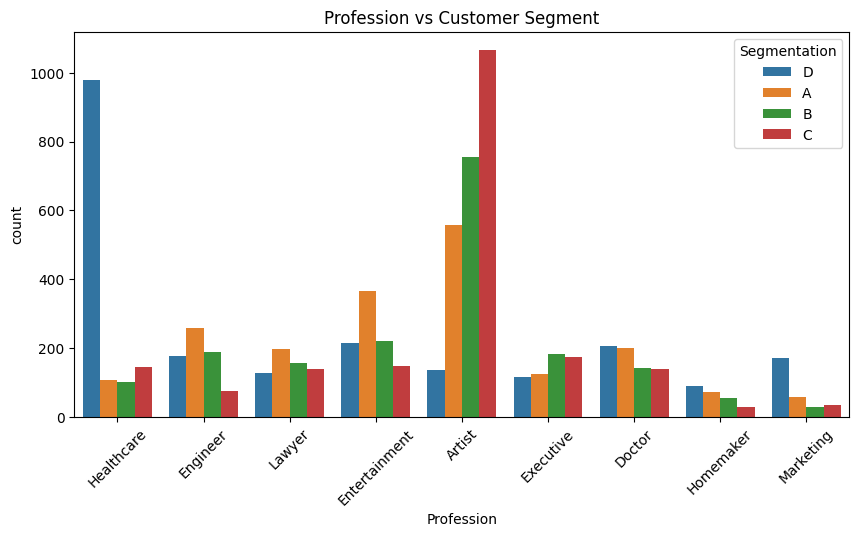

In [63]:
# Count of Professionals (Segment Wise)
plt.figure(figsize=(10,5))
sns.countplot(x='Profession', hue=target_col, data=df)
plt.xticks(rotation=45)
plt.title("Profession vs Customer Segment")
plt.show()


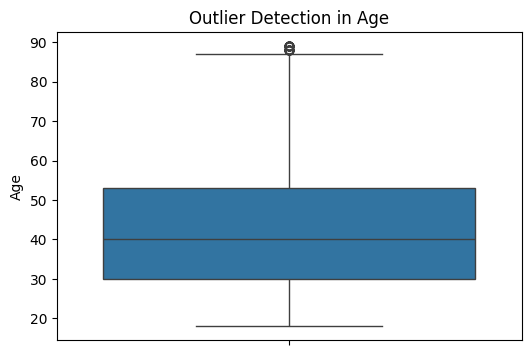

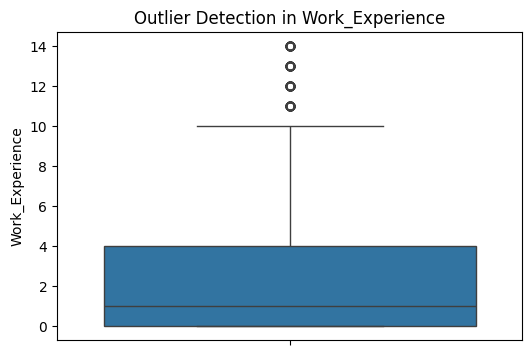

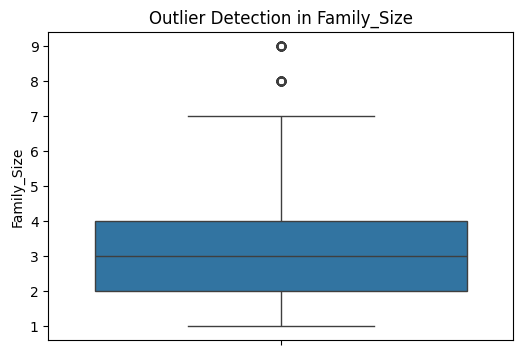

In [64]:
# Outlier Detection
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outlier Detection in {col}")
    plt.show()


# **DATA PREPROCESSING**


In [65]:
# Handling Missing Value
df[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[categorical_cols])
df[numerical_cols] = SimpleImputer(strategy='median').fit_transform(df[numerical_cols])

# Encoding
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df[target_col] = LabelEncoder().fit_transform(df[target_col])

# Feature Scaling
X = df.drop(columns=[target_col])
y = df[target_col]

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# **DATA SPLITTING**

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **MODEL TRAINING (NEURAL NETWORK, KNN, DECISION TREE)**

In [67]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=25),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=30,
        min_samples_leaf=25,
        class_weight='balanced',
        random_state=42
    ),
    "Neural Network": MLPClassifier(
      hidden_layer_sizes=(100, 10),
      activation='relu',
      alpha=0.0005,
      max_iter=10000,
      random_state=42
    )

}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training Model: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    predictions[name] = preds
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average='weighted'),
        "recall": recall_score(y_test, preds, average='weighted')
    }

    print(f"{name} Accuracy: {results[name]['accuracy']:.4f} ({results[name]['accuracy'] * 100:.2f}%)")
    print(f"{name} Precision: {results[name]['precision']:.4f} ({results[name]['precision'] * 100:.2f}%)")
    print(f"{name} Recall: {results[name]['recall']:.4f} ({results[name]['recall'] * 100:.2f}%)\n")

Training Model: KNN
KNN Accuracy: 0.5266 (52.66%)
KNN Precision: 0.5155 (51.55%)
KNN Recall: 0.5266 (52.66%)

Training Model: Decision Tree
Decision Tree Accuracy: 0.5118 (51.18%)
Decision Tree Precision: 0.5058 (50.58%)
Decision Tree Recall: 0.5118 (51.18%)

Training Model: Neural Network
Neural Network Accuracy: 0.5229 (52.29%)
Neural Network Precision: 0.5118 (51.18%)
Neural Network Recall: 0.5229 (52.29%)



# **MODEL COMPARISON**


--- MODEL COMPARISON ---

                accuracy  precision    recall
KNN             0.526642   0.515506  0.526642
Decision Tree   0.511772   0.505769  0.511772
Neural Network  0.522924   0.511777  0.522924


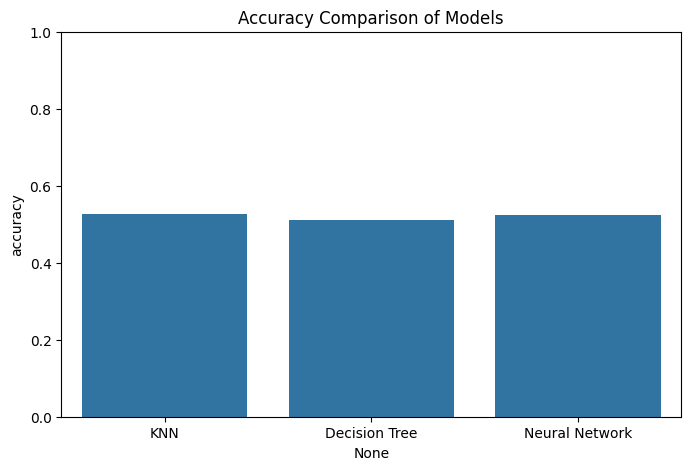

In [68]:
results_df = pd.DataFrame(results).T
print("\n--- MODEL COMPARISON ---\n")
print(results_df)

plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df['accuracy'])
plt.title("Accuracy Comparison of Models")
plt.ylim(0,1)
plt.show()

# **ROC CURVE & AUC (ALL 3 MODELS)**

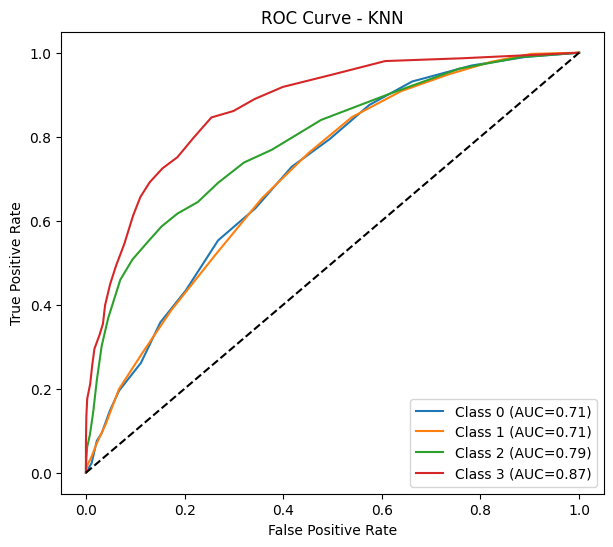

KNN Mean AUC Score: 0.7700


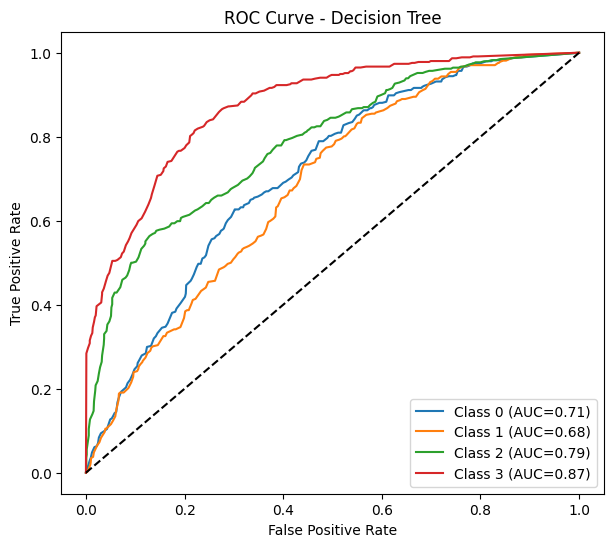

Decision Tree Mean AUC Score: 0.7628


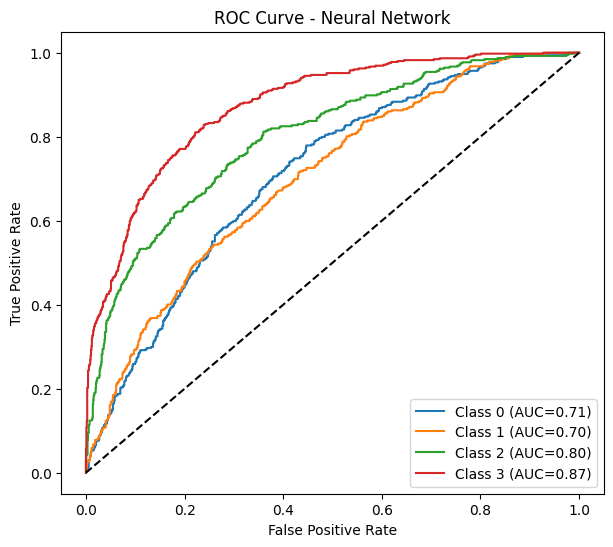

Neural Network Mean AUC Score: 0.7711


In [69]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

for name, model in models.items():
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(7,6))
    auc_scores = []

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        auc_scores.append(auc)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc:.2f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    print(f"{name} Mean AUC Score: {np.mean(auc_scores):.4f}")

# **CONFUSION MATRIX (BEST MODEL)**

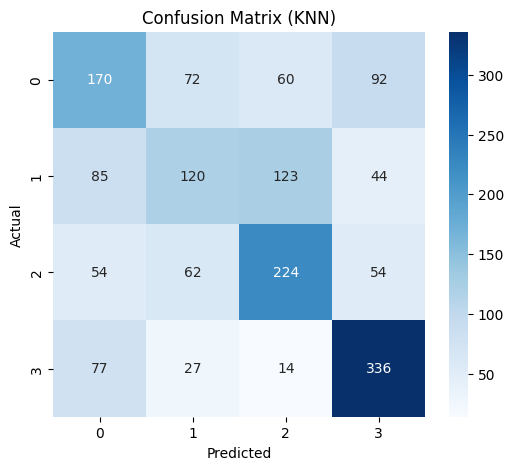

In [70]:
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = models[best_model_name]

cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **CONFUSION MATRIX FOR ALL THREE MODELS (NN, KNN, DECISION TREE)**

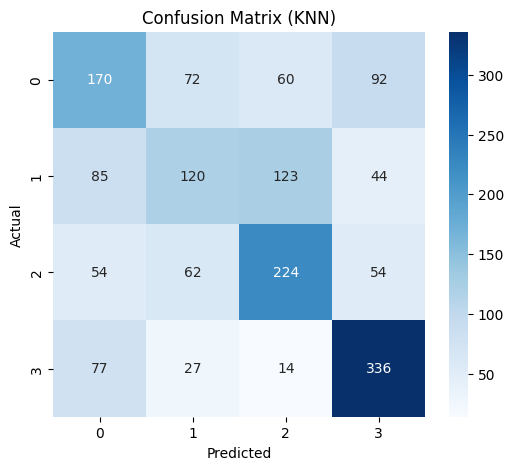

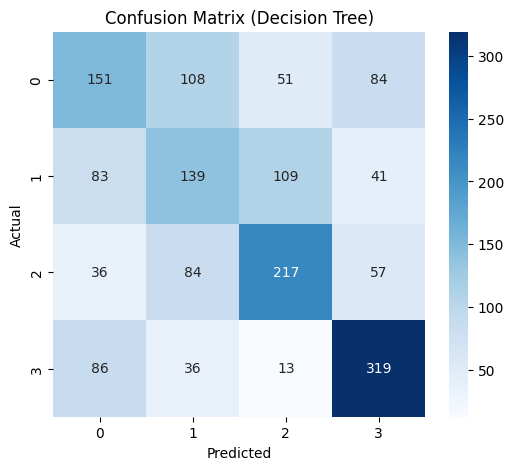

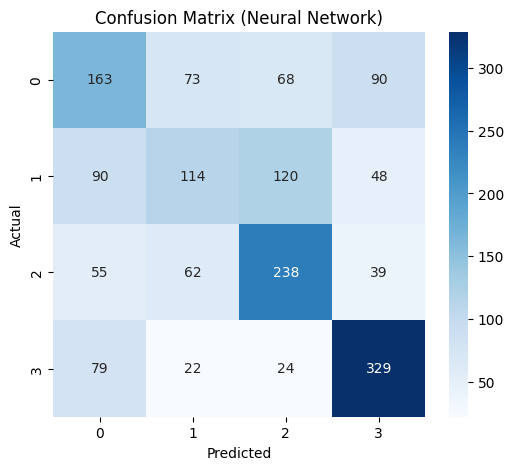

In [71]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# **UNSUPERVISED LEARNING (K-MEANS)**

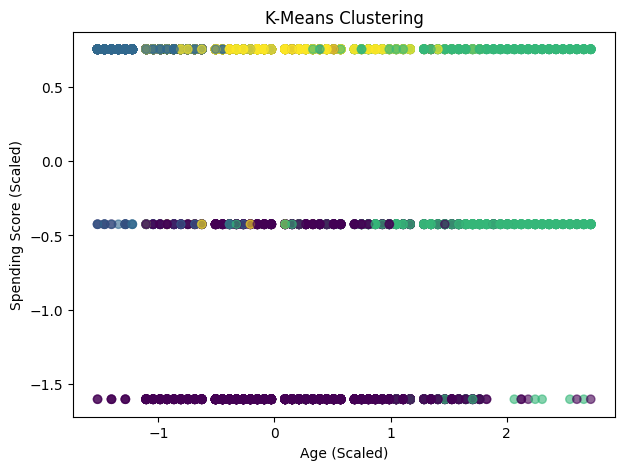

In [72]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(X['Age'], X['Spending_Score'], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel("Age (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("K-Means Clustering")
plt.show()

# **CONCLUSION**

In [73]:
print("\n--- CONCLUSION ---\n")
print(f"Best Performing Model: {best_model_name}")
print("Neural Network achieved strong performance due to its ability to learn complex patterns.")
print("KNN and Decision Tree also performed well but were sensitive to feature overlap.")
print("Proper data preprocessing and feature scaling were essential for stable results.")


--- CONCLUSION ---

Best Performing Model: KNN
Neural Network achieved strong performance due to its ability to learn complex patterns.
KNN and Decision Tree also performed well but were sensitive to feature overlap.
Proper data preprocessing and feature scaling were essential for stable results.
